# Epic of Sun - Desafio 1
Tunning the hyperparameters.
***

This jupyter notebook trains a UNet for sugarcane identification from satellite images.

It is divided in 5 parts:
* Loading libraries and data
* Separating the dataset in train, validate, and test sets
* Build the model
* Train the model
* Evaluate the model

***

## Loading libraries and data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

#import geopandas as gpd
#import rasterio
#from rasterio.features import rasterize

import json
import joblib
from pathlib import Path
import os

import tensorflow as tf
from sklearn.model_selection import train_test_split
#import segmentation_models as sm
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.models import load_model

import keras_tuner as kt

from sklearn.metrics import (
	classification_report, 
	confusion_matrix, 
	roc_auc_score,
	roc_curve,
	precision_recall_curve, 
    precision_score,
    recall_score,
    f1_score,
	recall_score)

2026-08-02 20:52:44.655595: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1785714765.449556  363869 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1785714765.670644  363869 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-08-02 20:52:47.539201: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Flags
flag_hyperparameter_tuning = False
flag_load_model = False

In [ ]:
# Get the directory where THIS script is located
base_path = Path.cwd()
base_path = base_path.parent  # Move one level up to the project root

In [4]:
# Specify the paths to the mesh and image files
patches_path = base_path / "data" / "processed"

In [5]:
patch_index = pd.read_csv(patches_path / "patch_index.csv")

print(patch_index.head())
print(len(patch_index))

     scene  patch_id  row_start  col_start  \
0  scene02         0          0          0   
1  scene02         1          0         64   
2  scene02         2          0        128   
3  scene02         3          0        192   
4  scene02         4          0        256   

                                   x_patch_path  \
0  data/processed/scene02/images/patch_0000.npy   
1  data/processed/scene02/images/patch_0001.npy   
2  data/processed/scene02/images/patch_0002.npy   
3  data/processed/scene02/images/patch_0003.npy   
4  data/processed/scene02/images/patch_0004.npy   

                                  y_patch_path  sugarcane_pixels  
0  data/processed/scene02/masks/patch_0000.npy                14  
1  data/processed/scene02/masks/patch_0001.npy                84  
2  data/processed/scene02/masks/patch_0002.npy                70  
3  data/processed/scene02/masks/patch_0003.npy                 0  
4  data/processed/scene02/masks/patch_0004.npy                 0  
5445


## Separating the dataset in train, validate, and test sets

In [12]:
# Select the scenes for training, validation, and testing
train_scenes = [
    "scene01",
    "scene02",
    "scene05",
]

val_scenes = [
    "scene03",
]

test_scenes = [
    "scene04",
]

In [13]:
# Get the unique scene names
scenes = patch_index["scene"].unique()

"""# Split scenes into train+val and test
train_val_scenes, test_scenes = train_test_split(
    scenes,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

# Split train+val scenes into train and validation
train_scenes, val_scenes = train_test_split(
    train_val_scenes,
    test_size=0.25,   # 25% of 80% = 20% overall
    random_state=42,
    shuffle=True
)"""

# Select patches belonging to those scenes
train_df = patch_index[
    patch_index["scene"].isin(train_scenes)
].reset_index(drop=True)

val_df = patch_index[
    patch_index["scene"].isin(val_scenes)
].reset_index(drop=True)

test_df = patch_index[
    patch_index["scene"].isin(test_scenes)
].reset_index(drop=True)

In [14]:
# Show the number of patches for each scene
print("\nTraining")
print(train_df.groupby("scene").size())

print("\nValidation")
print(val_df.groupby("scene").size())

print("\nTesting")
print(test_df.groupby("scene").size())


Training
scene
scene01    1089
scene02    1089
scene05    1089
dtype: int64

Validation
scene
scene03    1089
dtype: int64

Testing
scene
scene04    1089
dtype: int64


In [15]:
print(train_df["sugarcane_pixels"].mean())
print(val_df["sugarcane_pixels"].mean())
print(test_df["sugarcane_pixels"].mean())

4565.036424854607
5936.671258034894
7633.408631772269


In [16]:
# Function to add spectral indices to the input patches

def add_spectral_indices(X_data, eps=1e-8):
    """
    Appends spectral indices (NDVI, NDWI, EVI) as extra channels to input patches.
    
    Expected input shape: (..., H, W, 4) or (H, W, 4)
    Channels: [Blue (0), Green (1), Red (2), NIR (3)]
    """
    # Extract individual bands along the last axis
    blue  = X_data[..., 0]
    green = X_data[..., 1]
    red   = X_data[..., 2]
    nir   = X_data[..., 3]

    # 1. NDVI: (NIR - Red) / (NIR + Red)
    ndvi = (nir - red) / (nir + red + eps)

    # 2. NDWI: (Green - NIR) / (Green + NIR)
    ndwi = (green - nir) / (green + nir + eps)

    # 3. EVI: 2.5 * (NIR - Red) / (NIR + 6*Red - 7.5*Blue + 1)
    evi = 2.5 * (nir - red) / (nir + 6.0 * red - 7.5 * blue + 1.0 + eps)

    # Re-add channel dimension to calculated 2D indices
    ndvi = np.expand_dims(ndvi, axis=-1)
    ndwi = np.expand_dims(ndwi, axis=-1)
    evi  = np.expand_dims(evi, axis=-1)

    # Stack original bands with new index channels along the channel axis
    X_expanded = np.concatenate([X_data, ndvi, ndwi, evi], axis=-1)

    return X_expanded

In [ ]:
# PatchGenerator class for generating batches of patches for training, validation, and testing
class PatchGenerator(tf.keras.utils.Sequence):

    def __init__(
        self,
        dataframe,
        base_path,
        batch_size=32,
        shuffle=True,
        compute_indices=True
    ):

        self.df = dataframe.reset_index(drop=True)
        self.base_path = base_path
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.compute_indices = compute_indices

        self.indexes = np.arange(len(self.df))

        self.on_epoch_end()


    def __len__(self):
        return math.ceil(len(self.df) / self.batch_size)


    def on_epoch_end(self):

        if self.shuffle:
            np.random.shuffle(self.indexes)


    def __getitem__(self, batch_idx):

        start = batch_idx * self.batch_size
        end = min(start + self.batch_size, len(self.df))

        batch_indexes = self.indexes[start:end]

        X = []
        Y = []

        for idx in batch_indexes:

            row = self.df.iloc[idx]

            x_path = self.base_path / row["x_patch_path"]
            y_path = self.base_path / row["y_patch_path"]

            x = np.load(x_path)

            if x.dtype != np.float32:
                x = x.astype(np.float32)

            y = np.load(y_path)

            if y.dtype != np.float32:
                y = y.astype(np.float32)

            if self.compute_indices:
                x = add_spectral_indices(x)

            X.append(x)
            Y.append(y)

        return np.stack(X), np.stack(Y)

In [ ]:
# Create instances of PatchGenerator for training, validation, and testing
train_generator = PatchGenerator(
    train_df,
    base_path,
    batch_size=saved_params["batch_size"],
    shuffle=True,
    compute_indices=True
)

val_generator = PatchGenerator(
    val_df,
    base_path,
    batch_size=saved_params["batch_size"],
    shuffle=False,
    compute_indices=True
)

test_generator = PatchGenerator(
    test_df,
    base_path,
    batch_size=saved_params["batch_size"],
    shuffle=False,
    compute_indices=True
)

NameError: name 'saved_params' is not defined

## Build the Model

In [42]:
# Convolution block
# Each block performs Conv -> ReLU -> Conv -> ReLU

def conv_block(inputs, filters):

    x = layers.Conv2D(
        filters,
        3,
        padding="same",
        activation="relu"
    )(inputs)

    x = layers.Conv2D(
        filters,
        3,
        padding="same",
        activation="relu"
    )(x)

    return x

In [43]:
# Encoder block
# Each block performs:
#  extracts features
#  saves them for the skip connection
#  downsamples by 2

def encoder_block(inputs, filters):
    x = conv_block(inputs, filters)
    p = layers.MaxPooling2D((2,2))(x)
    return x, p

In [44]:
# Decoder block
# Each block performs:
#  upsamples
#  concatenates the skip connection
#  performs two convolutions

def decoder_block(inputs, skip, filters):

    x = layers.Conv2DTranspose(
        filters,
        2,
        strides=2,
        padding="same"
    )(inputs)
	
    x = layers.Concatenate()([x, skip])

    x = conv_block(x, filters)

    return x

In [45]:
# Function to build the network, compile it, use tunned hyperparameters, and return the model

def build_unet(input_shape=(128,128,7), init_filters=32, lr=1e-3):
    inputs = layers.Input(input_shape)
    
    # Encoder
    s1, p1 = encoder_block(inputs, init_filters)  # 32
    s2, p2 = encoder_block(p1, init_filters * 2)  # 64
    s3, p3 = encoder_block(p2, init_filters * 4)  # 128
    s4, p4 = encoder_block(p3, init_filters * 8)  # 256
    
    # Bottleneck
    b1 = conv_block(p4, init_filters * 16)        # 512
    
    # Decoder
    d1 = decoder_block(b1, s4, init_filters * 8)  # 256
    d2 = decoder_block(d1, s3, init_filters * 4)  # 128
    d3 = decoder_block(d2, s2, init_filters * 2)  # 64
    d4 = decoder_block(d3, s1, init_filters)      # 32
    
    # Output
    outputs = layers.Conv2D(1, 1, activation="sigmoid")(d4)
    model = Model(inputs, outputs)
    
    # Unified comilation with the original metrics
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(),
            tf.keras.metrics.Precision(),
            tf.keras.metrics.Recall()
        ]
    )
    return model

In [46]:
# Wrapper function for Keras Tuner to tune hyperparameters

def tune_wrapper(hp):
    # Define the hyperparameters to tune
	# 1. Structural hyperparameters
    hp_filters = hp.Choice("init_filters", values=[8, 16, 32, 64])
    hp_lr = hp.Float("lr", min_value=1e-5, max_value=1e-2, sampling="log")
    
	# 2. Training hyperparameter (Focused on hardware economy)
    hp.Choice("batch_size", values=[16, 32, 64, 128]) 

    # Call original build_unet function with the hyperparameters
    return build_unet(init_filters=hp_filters, lr=hp_lr)

In [ ]:
# Hyperparameter search

# Custom Tuner that successfully extracts and applies the batch size
class CustomRandomSearch(kt.RandomSearch):
    def run_trial(self, trial, *args, **kwargs):
        # Safely pull the active hyperparameter sample assigned by Keras Tuner
        hp = trial.hyperparameters
        
        # Inject it into kwargs so tf.keras.Model.fit receives it smoothly
        kwargs['batch_size'] = hp.get('batch_size') 
        return super(CustomRandomSearch, self).run_trial(trial, *args, **kwargs)

if flag_hyperparameter_tuning:
	# Configuration for low processing
	tuner = CustomRandomSearch(
		tune_wrapper,
		objective="val_loss",
		max_trials=30, # Number of different hyperparameter combinations to try
		executions_per_trial=1,
		directory="unet_tuner_results", # Directory to store the results of the hyperparameter search
		project_name="sugarcane_fast",
		overwrite=True # Cleans up older, failed configuration caches
	)

	# Stop early if the model is not improving to save time
	fast_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=2)

	# Execute the hyperparameter search
	tuner.search(
		train_generator,
		validation_data=val_generator,
		epochs=15,
		callbacks=[fast_stop]
	)
	# Extract and print the best hyperparameters
	best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
	print(f"Best learning rate: {best_hps.get('lr')}")
	print(f"Best init_filters:  {best_hps.get('init_filters')}")
	print(f"Best batch_size:    {best_hps.get('batch_size')}")

	# Save data in JSON file
	best_params = {
		"lr": best_hps.get("lr"), 
		"init_filters": best_hps.get("init_filters"),
		"batch_size": int(best_hps.get("batch_size"))
		}

	json_path = base_path / "models" / "best_sugarcane_params.json"
	with open(json_path, "w") as f:
		json.dump(best_params, f)
	print(f"Best hyperparameters saved to {json_path}")
else:
	print("Hyperparameter tuning is disabled. Using default parameters.")

Hyperparameter tuning is disabled. Using default parameters.


In [48]:
# Create the model with the best hyperparameters

# Load the best hyperparameters from the JSON file
json_path = base_path / "models" / "best_sugarcane_params.json"

with open(json_path, "r") as f:
    saved_params = json.load(f)

# Create the model with the best hyperparameters
model = build_unet(
    init_filters=saved_params["init_filters"], 
    lr=saved_params["lr"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 7)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 128, 128,  │      1,024 │ input_layer_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 128, 128,  │      2,320 │ conv2d_19[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 64, 64,    │          0 │ conv2d_20[0][0]   │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 64, 64,    │      4,640 │ max_pooling2d_4[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 64, 64,    │      9,248 │ conv2d_21[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 32, 32,    │          0 │ conv2d_22[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 32, 32,    │     18,496 │ max_pooling2d_5[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 32, 32,    │     36,928 │ conv2d_23[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 16, 16,    │          0 │ conv2d_24[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 16, 16,    │     73,856 │ max_pooling2d_6[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 16, 16,    │    147,584 │ conv2d_25[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 8, 8, 128) │          0 │ conv2d_26[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 8, 8, 256) │    295,168 │ max_pooling2d_7[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 8, 8, 256) │    590,080 │ conv2d_27[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_4  │ (None, 16, 16,    │    131,200 │ conv2d_28[0][0]   │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 16, 16,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 256)              │            │ conv2d_26[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,941,681 (7.41 MB)

 Trainable params: 1,941,681 (7.41 MB)

 Non-trainable params: 0 (0.00 B)

In [49]:
# You can just load the model if already trained and not run the random search and best model again

history_dict = None  # Initialize history_dict to None

if flag_load_model:
	model_path = base_path / "models" / "unet_sugarcane.keras"
	history_path = base_path / "models" / "training_history.json"

	if model_path.exists():
		try:
			# Pass str(model_path) to ensure compatibility
			model = load_model(str(model_path), compile=False)
			print("Successfully loaded saved model.")
		except Exception as e:
			print(f"File exists, but load_model failed with error:\n{e}")
	else:
		print("File does not exist at the specified path. Check your working directory or base_path.")
	
	if history_path.exists():
		try:
			with open(str(history_path), 'r') as f:
				history_dict = json.load(f)
			print("Successfully loaded saved training history.")
		except Exception as e:
			print(f"File exists, but loading training history failed with error:\n{e}")
	else:
		print("Training history file does not exist at the specified path. Check your working directory or base_path.")
else:
	print("Model loading skipped. Training a new model from scratch or using hyperparameter tuning results.")

Model loading skipped. Training a new model from scratch or using hyperparameter tuning results.


## Train the model

In [50]:
# Checkpoint callback to save the best model based on validation loss
model_path = base_path / "models" / "unet_sugarcane.keras"

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    model_path,
    monitor="val_loss",
    save_best_only=True
)

In [ ]:
# Checkpoint callback to stop training early if the validation loss does not improve for a certain number of epochs (patience)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [52]:
# Checkpoint callback to reduce learning rate when validation loss plateaus
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    verbose=1
)

In [ ]:
# Train the model
if not flag_load_model:
	print("Training a new model.")
	history = model.fit(
		train_generator,
		validation_data=val_generator,
		epochs=50,
		callbacks=[checkpoint, early_stop, reduce_lr],
		verbose=1
	)

	history_dict = history.history
else:
	print("Model loaded, skipping training.")

Training a new model.


2026-08-02 17:10:55.891637: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1598291968 exceeds 10% of free system memory.
2026-08-02 17:10:57.948548: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1598291968 exceeds 10% of free system memory.


Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 24s 222ms/step - binary_accuracy: 0.6585 - loss: 0.6227 - precision_1: 0.2859 - recall_1: 0.0238 - val_binary_accuracy: 0.6602 - val_loss: 0.6020 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00 - learning_rate: 5.4084e-04
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 143ms/step - binary_accuracy: 0.6735 - loss: 0.5491 - precision_1: 0.7020 - recall_1: 0.0171 - val_binary_accuracy: 0.6952 - val_loss: 0.5375 - val_precision_1: 0.6647 - val_recall_1: 0.2079 - learning_rate: 5.4084e-04
Epoch 3/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - binary_accuracy: 0.7344 - loss: 0.4882 - precision_1: 0.6174 - recall_1: 0.5116 - val_binary_accuracy: 0.7770 - val_loss: 0.4691 - val_precision_1: 0.7277 - val_recall_1: 0.5494 - learning_rate: 5.4084e-04
Epoch 4/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 105ms/step - binary_accuracy: 0.7768 - loss: 0.4511 - precision_1: 0.6622 - recall_1: 0.6597 - val_binary_accuracy: 0.7816 - val_loss: 0.4441 - val_precision_1: 0.6549

In [54]:
# Save the model and its history for future use.
# The model is saved in the Keras format (.keras) which includes both architecture and weights.

if not flag_load_model:
	# Save the model.
	model_path = base_path / "models" / "unet_sugarcane.keras"
	model.save(str(model_path))
	print(f"Model saved to '{model_path}'")

	# Save the training history as a JSON file for future reference.
	history_path = base_path / "models" / "training_history.json"
	with open(str(history_path), 'w') as f:
		json.dump(history_dict, f)
	print(f"Training history saved to '{history_path}'")
else:
	print("Model loaded, skipping saving model and history.")

Model saved to '/home/fdesmello/Git/spacesugar/models/unet_sugarcane.keras'
Training history saved to '/home/fdesmello/Git/spacesugar/models/training_history.json'


## Evaluate the model


Visualization saved as '/home/fdesmello/Git/spacesugar/figures/loss_accuracy.png'


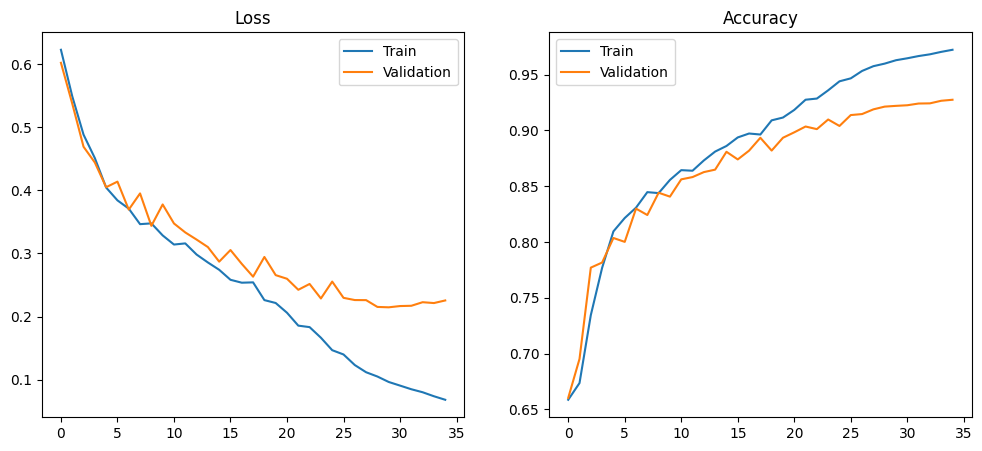

In [55]:
# Plot the learning curves

if history:
	plt.figure(figsize=(12,5))

	plt.subplot(1,2,1)
	plt.plot(history.history["loss"], label="Train")
	plt.plot(history.history["val_loss"], label="Validation")
	plt.title("Loss")
	plt.legend()

	plt.subplot(1,2,2)
	plt.plot(history.history["binary_accuracy"], label="Train")
	plt.plot(history.history["val_binary_accuracy"], label="Validation")
	plt.title("Accuracy")
	plt.legend()

	file_path = base_path / "figures" / "loss_accuracy.png"
	plt.savefig(file_path, dpi=300, bbox_inches='tight')
	print(f"\nVisualization saved as '{file_path}'")

	plt.show()
elif history_dict:
	plt.figure(figsize=(12,5))

	plt.subplot(1,2,1)
	plt.plot(history_dict["loss"], label="Train")
	plt.plot(history_dict["val_loss"], label="Validation")
	plt.title("Loss")
	plt.legend()

	plt.subplot(1,2,2)
	plt.plot(history_dict["binary_accuracy"], label="Train")
	plt.plot(history_dict["val_binary_accuracy"], label="Validation")
	plt.title("Accuracy")
	plt.legend()

	file_path = base_path / "figures" / "loss_accuracy.png"
	plt.savefig(file_path, dpi=300, bbox_inches='tight')
	print(f"\nVisualization saved as '{file_path}'")

	plt.show()
else:
	print("No training history available to plot learning curves.")

In [56]:
# Function to stretch the RGB values for better visualization
def stretch_rgb(rgb, low=2, high=98, gamma=2.2):
    rgb = rgb.copy()

    for b in range(3):
        p_low = np.percentile(rgb[:, :, b], low)
        p_high = np.percentile(rgb[:, :, b], high)

        rgb[:, :, b] = np.clip(rgb[:, :, b], p_low, p_high)
        rgb[:, :, b] = (rgb[:, :, b] - p_low) / (p_high - p_low)

    rgb = np.power(rgb, 1 / gamma)

    return rgb

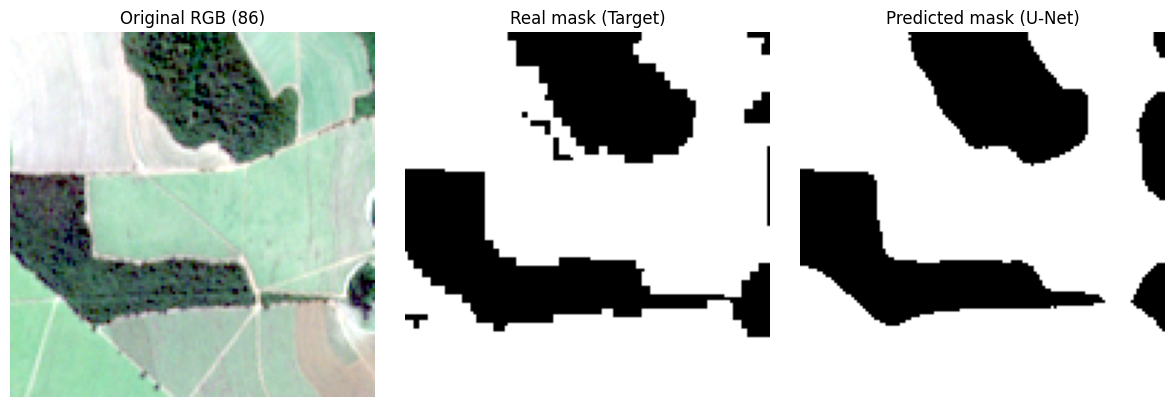

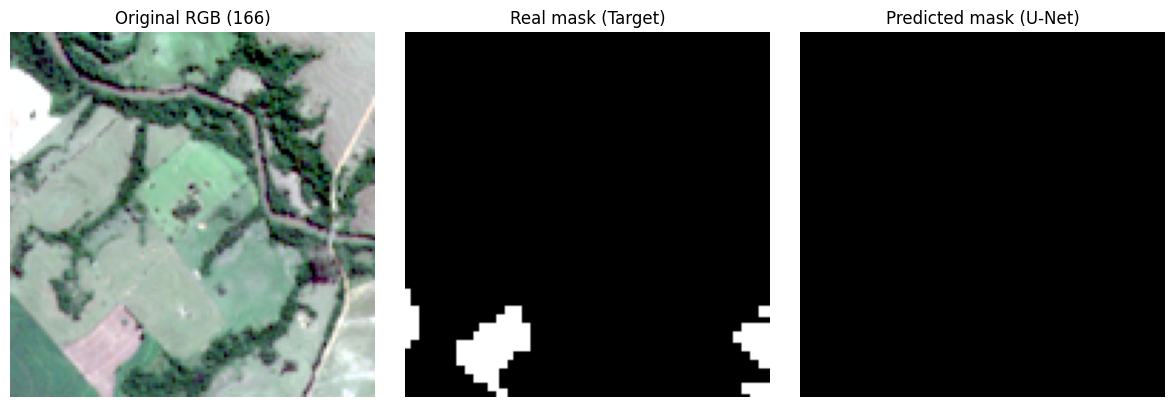

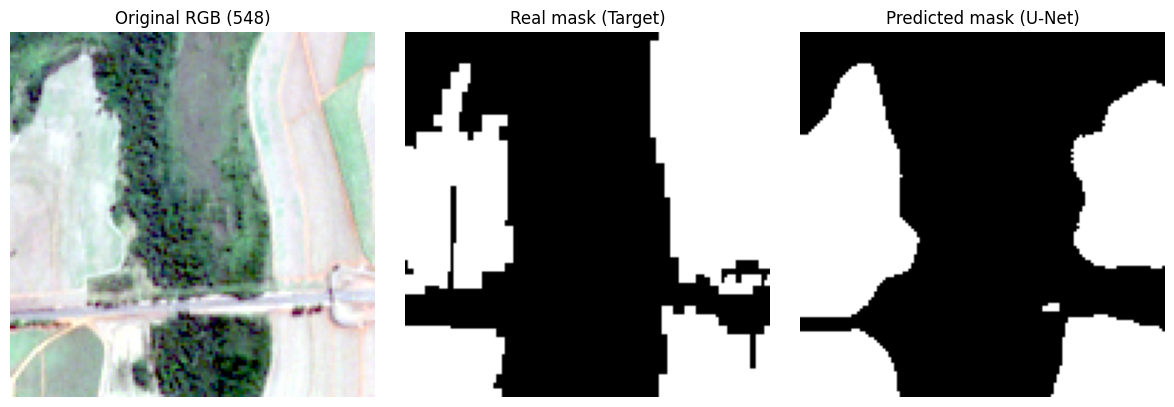

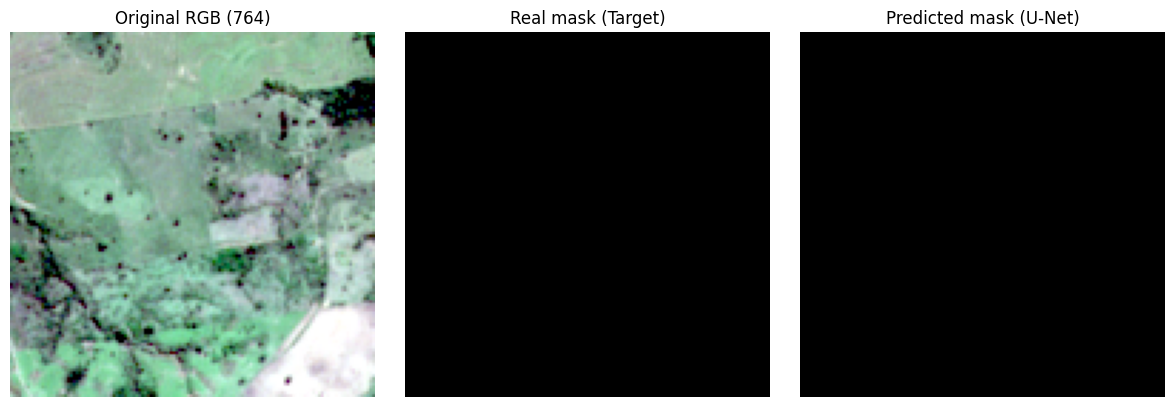

In [ ]:
# Make all the predictions on the test set and visualize 4 random results

max_plots = 4  # Number of images to visualize

all_predictions = []  # List to accumulate all predictions

j = 0 # Counter for saved figure filenames

i_numbers = random.sample(range(len(X_test)), k=max_plots) # Randomly select indices for visualization

for i in range(len(X_test)):
    # 1. Extract single image and make prediction
    single_img = X_test[i][np.newaxis, ...]
    pred = model.predict(single_img, verbose=0)
    
    # Remove batch dimension
    pred_squeezed = pred[0]
    all_predictions.append(pred_squeezed)
    
    # 2. VISUALIZATION SETUP (Only for X images)
    if i in i_numbers:
        binary_pred = pred_squeezed > 0.5
        fig, ax = plt.subplots(1, 3, figsize=(12, 4))
        
        # Extract RGB channels [Red=2, Green=1, Blue=0]
        # Clip to [0, 1] bounds so matplotlib displays colors accurately
        rgb = np.clip(X_test[i][::1, ::1, [2, 1, 0]], 0, 1).copy()
        #rgb = rgb[:, :, [2, 1, 0]] # If the bands are in BGR order, you can use this line instead to convert to RGB
        rgb = stretch_rgb(rgb)

        ax[0].imshow(rgb)
        ax[0].set_title(f"Original RGB ({i})")
        ax[0].axis('off')
        
        ax[1].imshow(y_test[i].squeeze(), cmap='gray')
        ax[1].set_title("Real mask (Target)")
        ax[1].axis('off')
        
        ax[2].imshow(binary_pred.squeeze(), cmap='gray')
        ax[2].set_title("Predicted mask (U-Net)")
        ax[2].axis('off')
        
        file_path = base_path / "figures" / f"unet_sugarcane_results_{j}.png"
        file_path.parent.mkdir(parents=True, exist_ok=True)
        j += 1
        
        plt.tight_layout()
        plt.savefig(file_path, dpi=300, bbox_inches='tight')
        plt.show()

In [58]:
# Metrics Calculation

# 1. Convert all collected predictions into a matching NumPy array
# Shape will become (N, H, W, C) matching y_train
y_pred_all = np.array(all_predictions)

# 2. Transform both entire sets into binary integers
y_pred_bin = (y_pred_all > 0.5).astype(int)
y_true_bin = y_test.astype(int)

# 3. Flatten the entire sets to 1D arrays
y_true_flat = y_true_bin.ravel()
y_pred_flat = y_pred_bin.ravel()

# 3.5. Calculate float probailities
y_true_float = y_test.astype(float).ravel()
y_pred_float = y_pred_all.astype(float).ravel()

# 4. Calculate global metrics
p = precision_score(y_true_flat, y_pred_flat, zero_division=0)
r = recall_score(y_true_flat, y_pred_flat, zero_division=0)
f1 = f1_score(y_true_flat, y_pred_flat, zero_division=0)
roc_auc = roc_auc_score(y_true_flat, y_pred_flat)

print(f"Metrics for the test dataset:")
print(f"Precision: {p:.4f}")
print(f"Recall: {r:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")

# 5. Intersection over Union (IoU) for the sugarcane class
# Instantiate the metric object
# target_class_ids=[1] isolates the sugarcane class, ignoring background pixels
iou_metric = tf.keras.metrics.BinaryIoU(target_class_ids=[1], threshold=0.5)

# Update the metric state with true masks and predicted probabilities
iou_metric.update_state(y_true_flat, y_pred_flat)

# Extract and print the final result
final_iou = iou_metric.result().numpy()
print(f"IoU: {final_iou:.4f}")

# 6. Confusion Matrix
cm = confusion_matrix(y_true_flat, y_pred_flat)
print("\nConfusion Matrix:")
print(cm)

# 7. Classification Report
print("\nClassification Report:")
print(classification_report(y_true_flat, y_pred_flat, zero_division=0))

Metrics for the test dataset:
Precision: 0.8850
Recall: 0.8911
F1-Score: 0.8880
ROC AUC Score: 0.9161
IoU: 0.7986

Confusion Matrix:
[[11129539   696806]
 [  655096  5360735]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94  11826345
           1       0.88      0.89      0.89   6015831

    accuracy                           0.92  17842176
   macro avg       0.91      0.92      0.92  17842176
weighted avg       0.92      0.92      0.92  17842176



/tmp/ipykernel_69346/3157514157.py:81: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/tmp/ipykernel_69346/3157514157.py:84: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(file_path, dpi=300, bbox_inches='tight')



Visualization saved as '/home/fdesmello/Git/spacesugar/figures/unet_sugarcane_results.png'


/home/fdesmello/miniconda3/envs/sugarcane/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


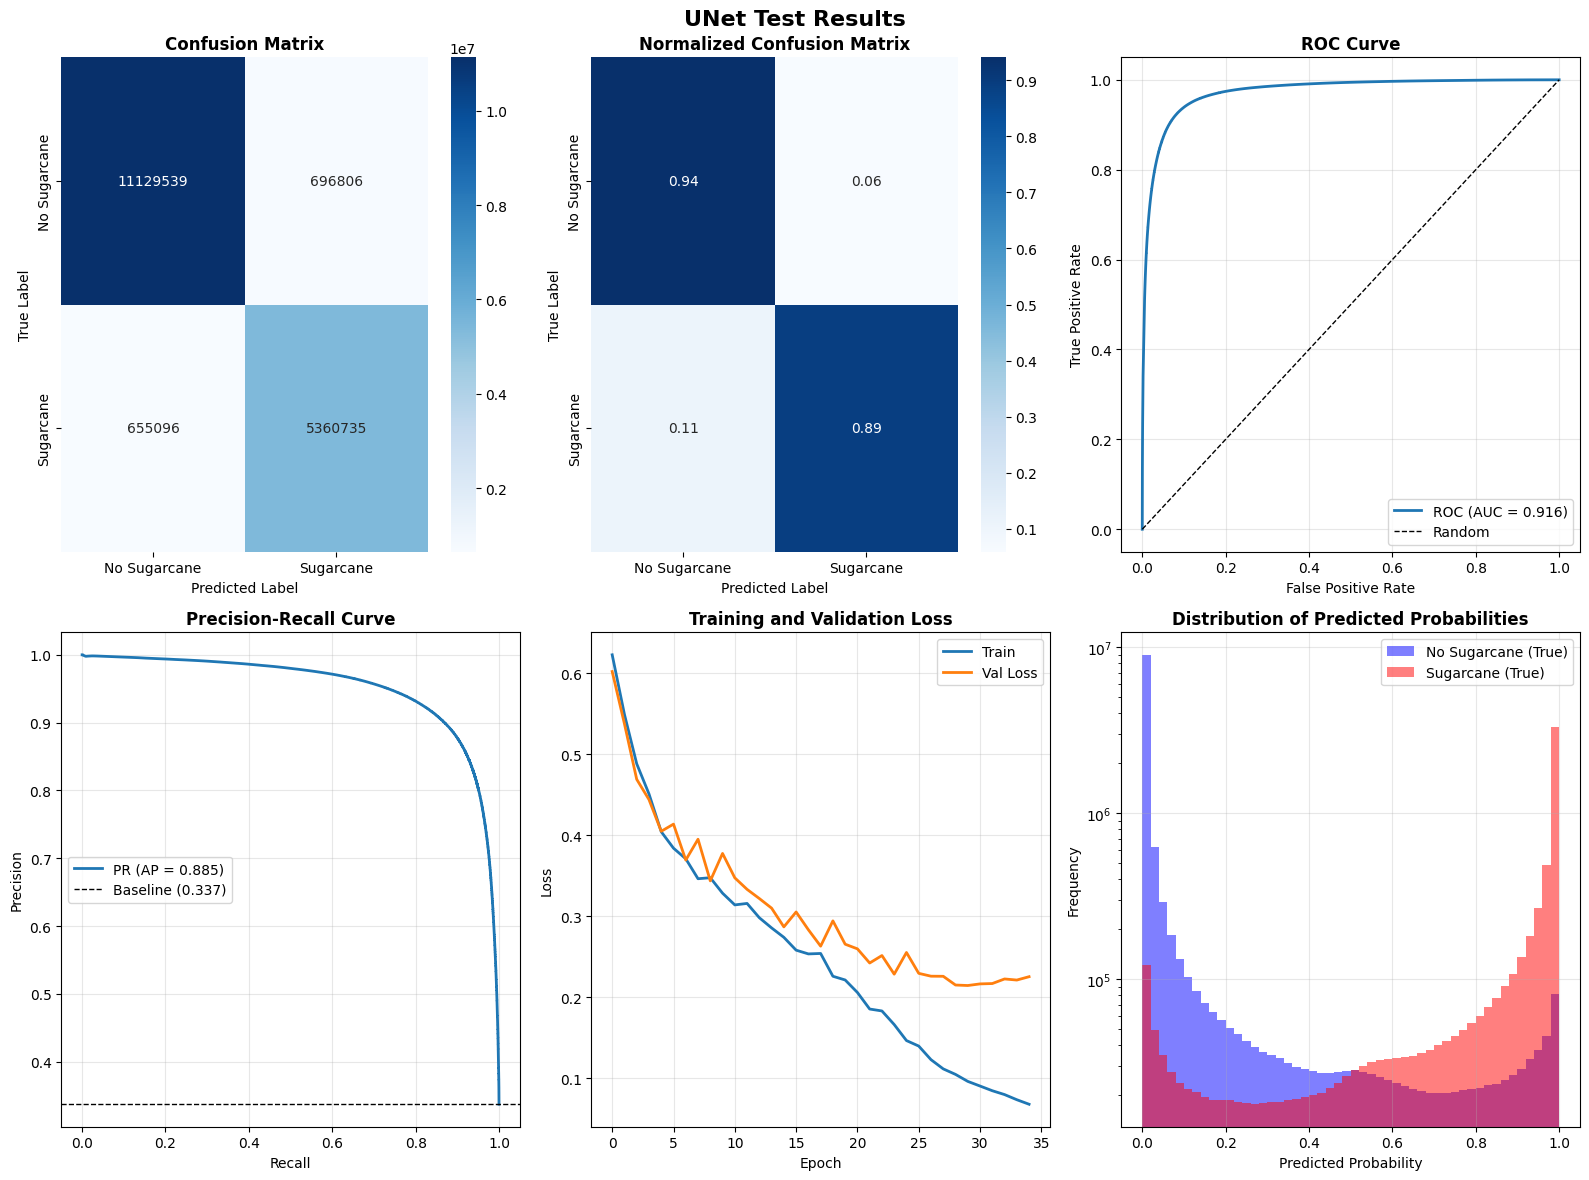

In [59]:
# Visualizations

fig = plt.figure(figsize=(16, 12))
plt.suptitle('UNet Test Results', fontsize=16, fontweight='bold')

class_names = ['No Sugarcane', 'Sugarcane']

# 1. Confusion Matrix
ax1 = plt.subplot(2, 3, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, xticklabels=class_names, yticklabels=class_names)
ax1.set_title('Confusion Matrix', fontsize=12, fontweight='bold')
ax1.set_ylabel('True Label')
ax1.set_xlabel('Predicted Label')

# 2. Normalized Confusion Matrix
cm_norm = pd.DataFrame(cm).apply(lambda x: x/sum(x), axis = 1)
ax2 = plt.subplot(2, 3, 2)
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap='Blues', ax=ax2, xticklabels=class_names, yticklabels=class_names)
ax2.set_title('Normalized Confusion Matrix', fontsize=12, fontweight='bold')
ax2.set_ylabel('True Label')
ax2.set_xlabel('Predicted Label')

# 3. ROC Curve
if len(np.unique(y_true_float)) > 1:
    ax3 = plt.subplot(2, 3, 3)
    fpr, tpr, _ = roc_curve(y_true_flat, y_pred_float)
    ax3.plot(fpr, tpr, linewidth=2, label=f'ROC (AUC = {roc_auc:.3f})')
    ax3.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
    ax3.set_xlabel('False Positive Rate')
    ax3.set_ylabel('True Positive Rate')
    ax3.set_title('ROC Curve', fontsize=12, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

# 4. Precision-Recall Curve
if len(np.unique(y_true_float)) > 1:
    ax4 = plt.subplot(2, 3, 4)
    precision, recall, _ = precision_recall_curve(y_true_flat, y_pred_float)
    ax4.plot(recall, precision, linewidth=2, label=f'PR (AP = {p:.3f})')
    ax4.axhline(y=y_true_flat.mean(), color='k', linestyle='--', linewidth=1, 
                label=f'Baseline ({y_true_flat.mean():.3f})')
    ax4.set_xlabel('Recall')
    ax4.set_ylabel('Precision')
    ax4.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

# 5. Training and Validation Loss
if history is not None:
	hist = history.history
	ax5 = plt.subplot(2, 3, 5)
	ax5.plot(history.history["loss"], label="Train", linewidth=2)
	ax5.plot(history.history["val_loss"], label="Val Loss", linewidth=2)
	ax5.set_xlabel('Epoch')
	ax5.set_ylabel('Loss')
	ax5.set_title('Training and Validation Loss', fontsize=12, fontweight='bold')
	ax5.legend()
	ax5.grid(True, alpha=0.3)
elif history_dict is not None:
    ax5 = plt.subplot(2, 3, 5)
    ax5.plot(history_dict["loss"], label='Train Loss', linewidth=2)
    ax5.plot(history_dict["val_loss"], label='Val Loss', linewidth=2)
    ax5.set_xlabel('Epoch')
    ax5.set_ylabel('Loss')
    ax5.set_title('Training and Validation Loss', fontsize=12, fontweight='bold')
    ax5.legend()
    ax5.grid(True, alpha=0.3)


# 6. Prediction Probability Distribution
ax6 = plt.subplot(2, 3, 6)
ax6.hist(y_pred_float[y_true_flat == 0], bins=50, alpha=0.5, label='No Sugarcane (True)', color='blue')
ax6.hist(y_pred_float[y_true_flat == 1], bins=50, alpha=0.5, label='Sugarcane (True)', color='red')
ax6.set_xlabel('Predicted Probability')
ax6.set_ylabel('Frequency')
ax6.set_yscale('log')
ax6.set_title('Distribution of Predicted Probabilities', fontsize=12, fontweight='bold')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()

file_path = base_path / "figures" / "unet_sugarcane_results.png"
plt.savefig(file_path, dpi=300, bbox_inches='tight')
print(f"\nVisualization saved as '{file_path}'")

plt.show()